In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import pickle

df=pd.read_csv('labeled_selected_routes_group_1.csv')

# przykładowo 6 równych kwantyli (możesz zmienić na 5,7)
df['delay_bin_q'] = pd.qcut(df['delay_min'].clip(lower=0), q=6, labels=False, duplicates='drop')

# df[df['delay_min']<-200]
df

,Unnamed: 0.1,Unnamed: 0,vehicle_id,trip_id,stop_sequence,day,planned_departure,timestamp,delay_sec,delay_min,route_name,time_label,delay_label,sin_time,cos_time,delay_bin_q
0,0,2,53,block_487_trip_6_service_1,14,2,2025-06-03 10:22:00,2025-06-03 10:25:59,239.0,3.983333,503,1020,3,0.422618,-0.906308,3
1,1,5,61,block_147_trip_7_service_1,3,2,2025-06-03 10:24:00,2025-06-03 10:25:59,119.0,1.983333,469,1020,2,0.422618,-0.906308,2
2,2,14,283,block_220_trip_8_service_1,15,2,2025-06-03 10:25:00,2025-06-03 10:25:57,57.0,0.950000,192,1025,1,0.402747,-0.915311,1
3,3,30,2,block_199_trip_8_service_1,3,2,2025-06-03 10:26:00,2025-06-03 10:26:29,29.0,0.483333,179,1025,1,0.402747,-0.915311,1
4,4,32,27,block_196_trip_7_service_1,16,2,2025-06-03 10:25:00,2025-06-03 10:26:29,89.0,1.483333,179,1025,2,0.402747,-0.915311,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140812,142204,1349865,573,block_964_trip_13_service_3,23,7,2025-06-29 23:34:00,2025-06-29 23:35:28,88.0,1.466667,469,2330,2,-0.130526,0.991445,2
140813,142205,1349869,573,block_964_trip_13_service_3,25,7,2025-06-29 23:40:00,2025-06-29 23:42:03,123.0,2.050000,469,2340,2,-0.087156,0.996195,2
140814,142206,1349870,573,block_964_trip_13_service_3,26,7,2025-06-29 23:43:00,2025-06-29 23:45:05,125.0,2.083333,469,2340,2,-0.087156,0.996195,2
140815,142207,1349873,573,block_964_trip_13_service_3,27,7,2025-06-29 23:45:00,2025-06-29 23:46:33,93.0,1.550000,469,2345,2,-0.065403,0.997859,2


In [35]:

objs = []
with open('../data/wyniki_predykcji/grupa_1_klasyfikacja_bez_cv_100_epoch','rb') as f:
    while True:
        try:
            objs.append(pickle.load(f))
        except EOFError:
            break

wyniki_zapis=objs[-1]


<Figure size 1200x500 with 0 Axes>

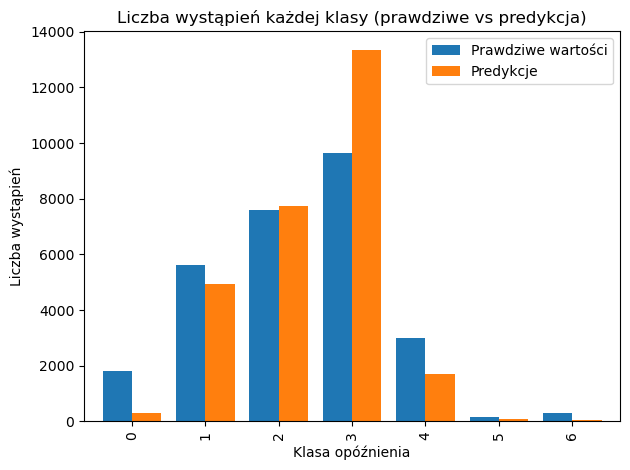

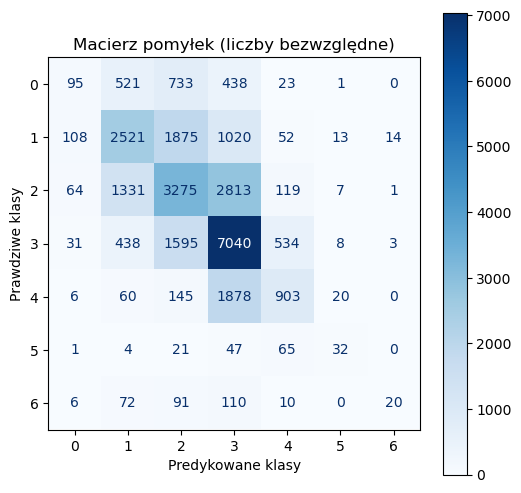

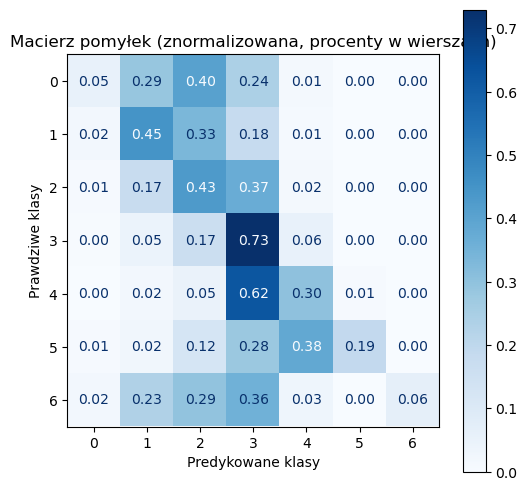

Precision dla każdej klasy:
Klasa 0: 0.305
Klasa 1: 0.510
Klasa 2: 0.423
Klasa 3: 0.527
Klasa 4: 0.529
Klasa 5: 0.395
Klasa 6: 0.526

Recall dla każdej klasy:
Klasa 0: 0.052
Klasa 1: 0.450
Klasa 2: 0.430
Klasa 3: 0.730
Klasa 4: 0.300
Klasa 5: 0.188
Klasa 6: 0.065

Średnia precision (macro): 0.460
Średnia recall (macro): 0.316


In [36]:
df_results = wyniki_zapis[2]
df_results = df_results.sort_values('orig_idx', ascending=True).set_index('orig_idx')

plt.figure(figsize=(12,5))
y_true_counts = df_results['y_true'].value_counts().sort_index()
y_pred_counts = df_results['y_pred'].value_counts().sort_index()

df_counts = pd.DataFrame({
    "Prawdziwe wartości": y_true_counts,
    "Predykcje": y_pred_counts
}).fillna(0).astype(int)

df_counts.plot(kind="bar", width=0.8)
plt.xlabel("Klasa opóźnienia")
plt.ylabel("Liczba wystąpień")
plt.title("Liczba wystąpień każdej klasy (prawdziwe vs predykcja)")
plt.legend()
plt.tight_layout()
plt.show()

cm = confusion_matrix(df_results['y_true'], df_results['y_pred'])
classes = sorted(df_results['y_true'].unique())

# Standard confusion matrix (absolute)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title(f"Macierz pomyłek (liczby bezwzględne)")
plt.xlabel("Predykowane klasy")
plt.ylabel("Prawdziwe klasy")
plt.show()

# Normalized confusion matrix (row norm)
cm_normalized = confusion_matrix(df_results['y_true'], df_results['y_pred'], normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=classes)
fig, ax = plt.subplots(figsize=(6, 6))
disp_norm.plot(ax=ax, cmap='Blues', values_format=".2f")
plt.title(f"Macierz pomyłek (znormalizowana, procenty w wierszach)")
plt.xlabel("Predykowane klasy")
plt.ylabel("Prawdziwe klasy")
plt.show()


precision = precision_score(df_results['y_true'], df_results['y_pred'], average=None, zero_division=0)
recall = recall_score(df_results['y_true'], df_results['y_pred'], average=None, zero_division=0)

print("Precision dla każdej klasy:")
for c, p in zip(classes, precision):
    print(f"Klasa {c}: {p:.3f}")
print("\nRecall dla każdej klasy:")
for c, r in zip(classes, recall):
    print(f"Klasa {c}: {r:.3f}")

print(f"\nŚrednia precision (macro): {precision_score(df_results['y_true'], df_results['y_pred'], average='macro', zero_division=0):.3f}")
print(f"Średnia recall (macro): {recall_score(df_results['y_true'], df_results['y_pred'], average='macro', zero_division=0):.3f}")

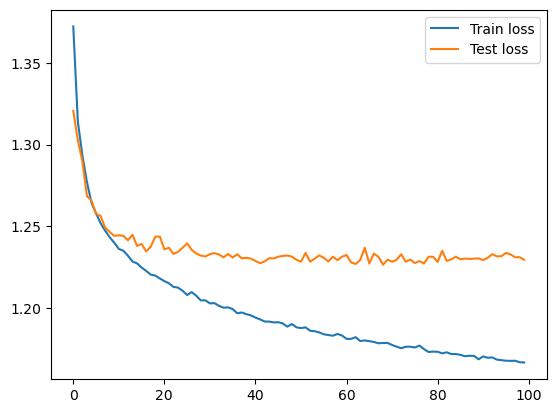

In [37]:
plt.figure
plt.plot(wyniki_zapis[0],label='Train loss')
plt.plot(wyniki_zapis[1],label='Test loss')
# plt.ylim([0,5])
plt.legend()
plt.show()

In [38]:
objs = []
with open('../data/wyniki_predykcji/grupa_1_klasyfikacja_5cv_100_epoch','rb') as f:
    while True:
        try:
            objs.append(pickle.load(f))
        except EOFError:
            break


wyniki=objs[-1]
for i in range(5):
    wyniki['fold_preds'][i] = wyniki['fold_preds'][i].sort_values('orig_idx', ascending=True).set_index('orig_idx')

print(wyniki['cv_losses'])

[1.222253574444367, 1.235945955590085, 1.2303314085479256, 1.2307872906461492, 1.2387641802564398]


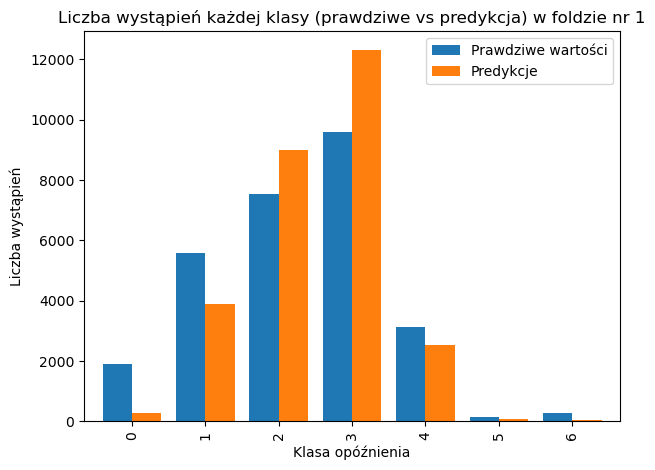

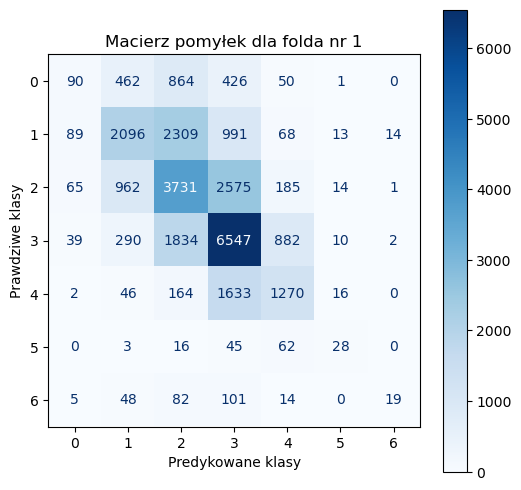

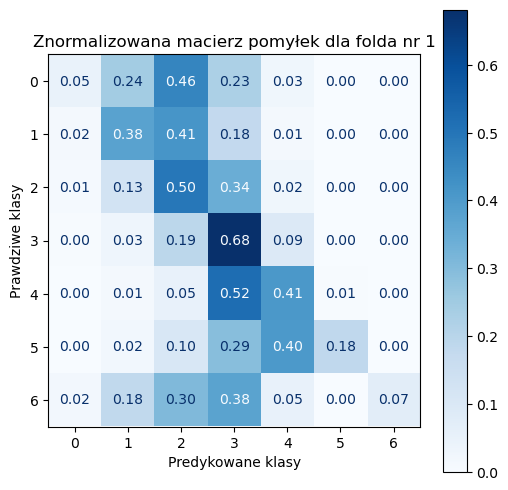

Fold 1:
  Klasa 0: precision = 0.310, recall = 0.048
  Klasa 1: precision = 0.536, recall = 0.376
  Klasa 2: precision = 0.415, recall = 0.495
  Klasa 3: precision = 0.531, recall = 0.682
  Klasa 4: precision = 0.502, recall = 0.406
  Klasa 5: precision = 0.341, recall = 0.182
  Klasa 6: precision = 0.528, recall = 0.071
  Macro Precision: 0.452, Macro Recall: 0.323



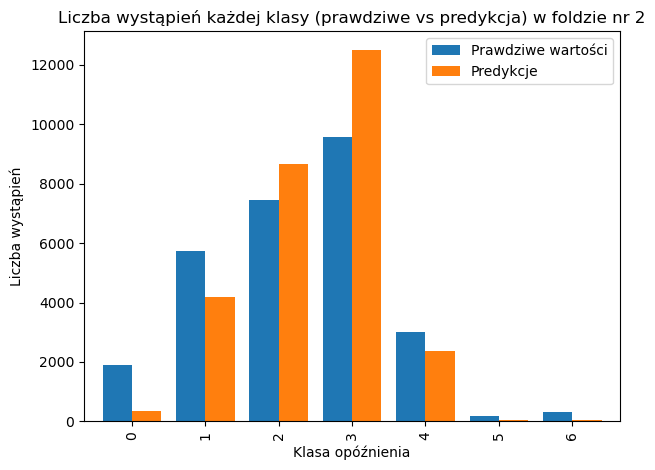

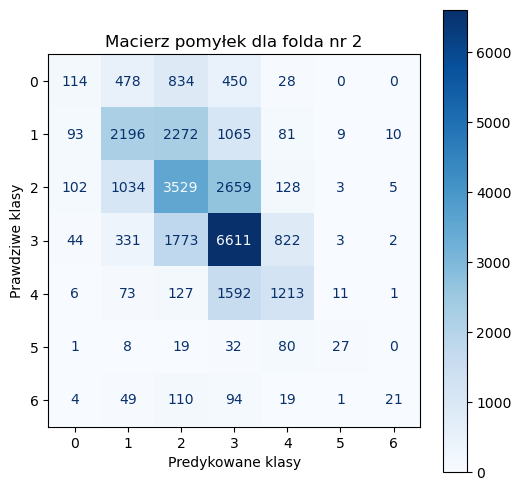

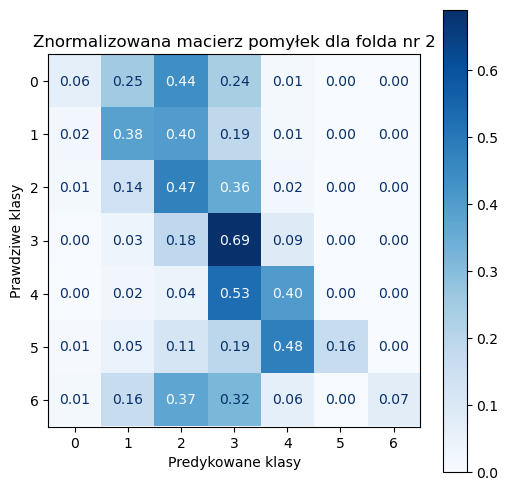

Fold 2:
  Klasa 0: precision = 0.313, recall = 0.060
  Klasa 1: precision = 0.527, recall = 0.384
  Klasa 2: precision = 0.407, recall = 0.473
  Klasa 3: precision = 0.529, recall = 0.690
  Klasa 4: precision = 0.512, recall = 0.401
  Klasa 5: precision = 0.500, recall = 0.162
  Klasa 6: precision = 0.538, recall = 0.070
  Macro Precision: 0.475, Macro Recall: 0.320



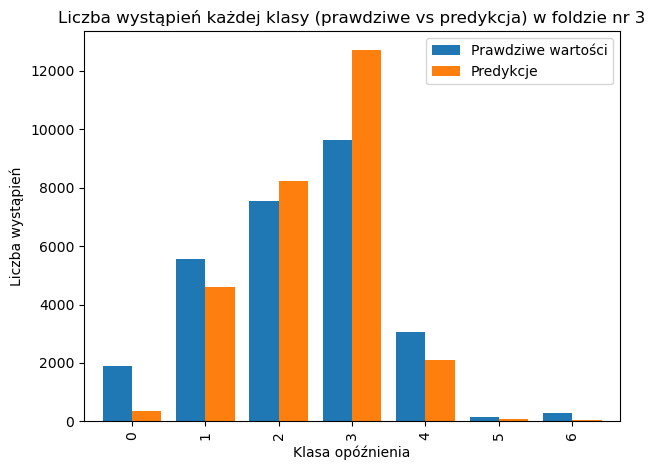

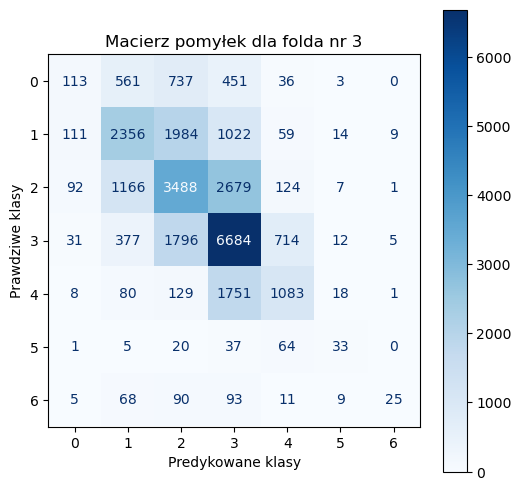

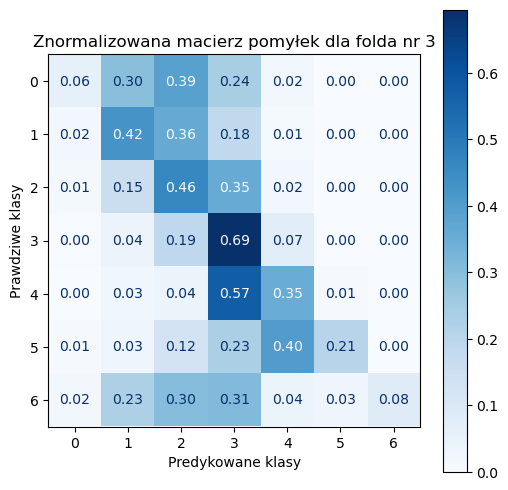

Fold 3:
  Klasa 0: precision = 0.313, recall = 0.059
  Klasa 1: precision = 0.511, recall = 0.424
  Klasa 2: precision = 0.423, recall = 0.462
  Klasa 3: precision = 0.526, recall = 0.695
  Klasa 4: precision = 0.518, recall = 0.353
  Klasa 5: precision = 0.344, recall = 0.206
  Klasa 6: precision = 0.610, recall = 0.083
  Macro Precision: 0.463, Macro Recall: 0.326



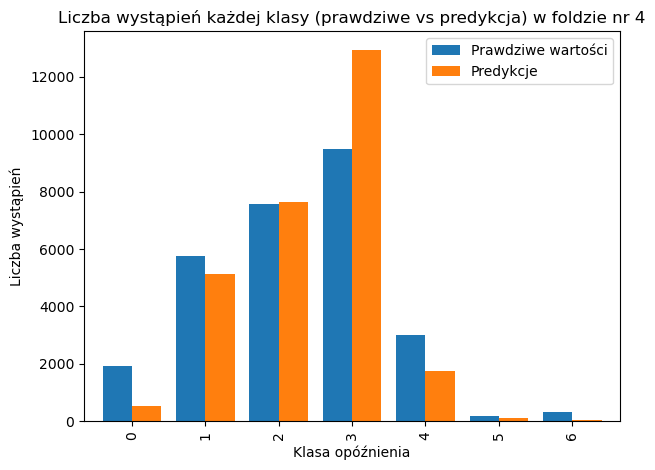

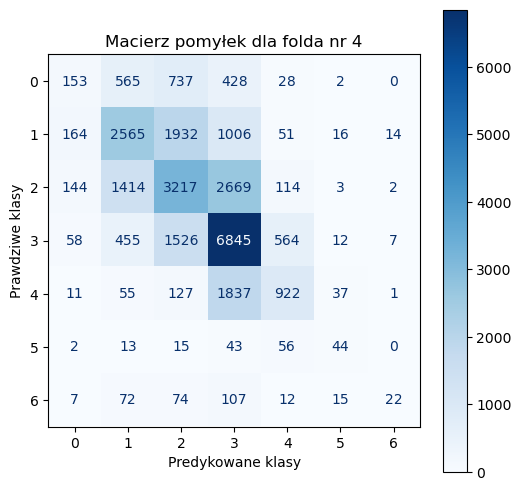

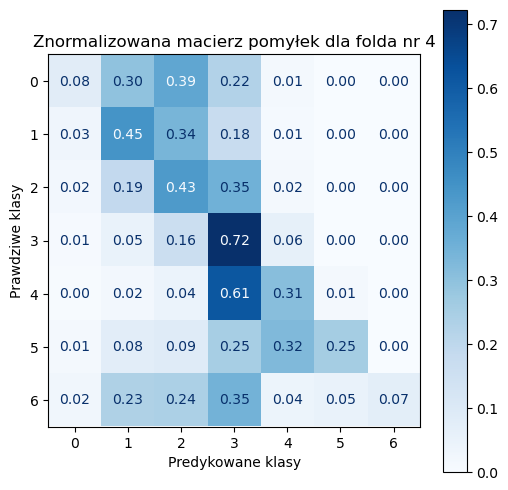

Fold 4:
  Klasa 0: precision = 0.284, recall = 0.080
  Klasa 1: precision = 0.499, recall = 0.446
  Klasa 2: precision = 0.422, recall = 0.425
  Klasa 3: precision = 0.529, recall = 0.723
  Klasa 4: precision = 0.528, recall = 0.308
  Klasa 5: precision = 0.341, recall = 0.254
  Klasa 6: precision = 0.478, recall = 0.071
  Macro Precision: 0.440, Macro Recall: 0.330



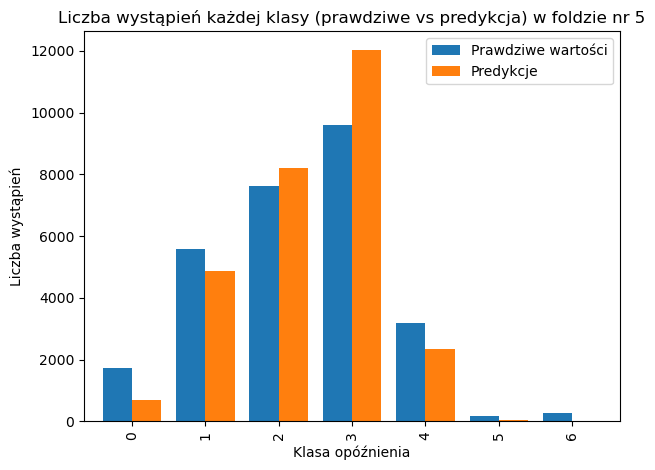

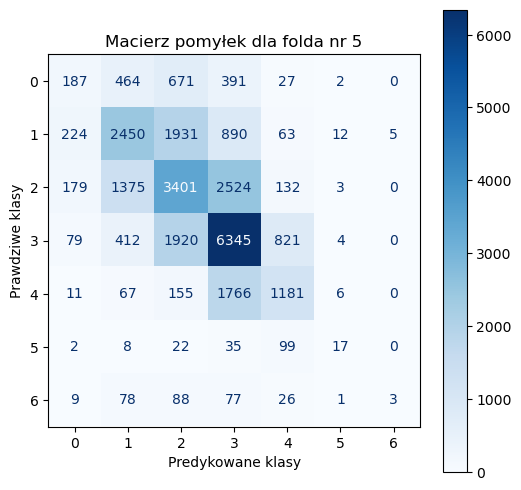

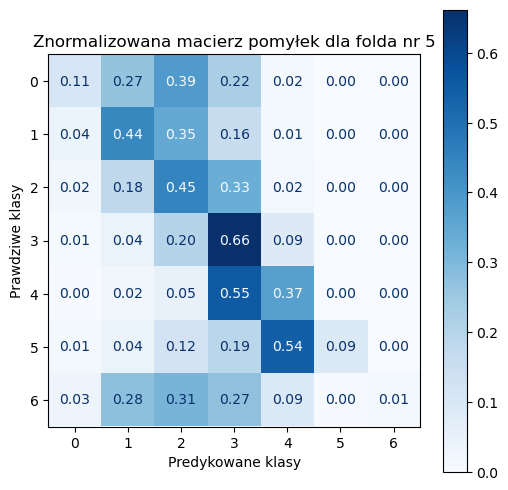

Fold 5:
  Klasa 0: precision = 0.271, recall = 0.107
  Klasa 1: precision = 0.505, recall = 0.439
  Klasa 2: precision = 0.415, recall = 0.447
  Klasa 3: precision = 0.528, recall = 0.662
  Klasa 4: precision = 0.503, recall = 0.371
  Klasa 5: precision = 0.378, recall = 0.093
  Klasa 6: precision = 0.375, recall = 0.011
  Macro Precision: 0.425, Macro Recall: 0.304



In [39]:

for i in range(5):
    predykcje = wyniki['fold_preds'][i]
    y_true_counts = predykcje['y_true'].value_counts().sort_index()
    y_pred_counts = predykcje['y_pred'].value_counts().sort_index()
    df_counts = pd.DataFrame({
        "Prawdziwe wartości": y_true_counts,
        "Predykcje": y_pred_counts
    }).fillna(0).astype(int)

    df_counts.plot(kind="bar", width=0.8)
    plt.xlabel("Klasa opóźnienia")
    plt.ylabel("Liczba wystąpień")
    plt.title(f"Liczba wystąpień każdej klasy (prawdziwe vs predykcja) w foldzie nr {i+1}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    cm = confusion_matrix(predykcje['y_true'], predykcje['y_pred'])
    classes = sorted(predykcje['y_true'].unique())

    # Standard confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap='Blues')
    plt.title(f"Macierz pomyłek dla folda nr {i+1}")
    plt.xlabel("Predykowane klasy")
    plt.ylabel("Prawdziwe klasy")
    plt.show()

    # Normalized confusion matrix
    cm_norm = confusion_matrix(predykcje['y_true'], predykcje['y_pred'], normalize='true')
    disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=classes)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp_norm.plot(ax=ax, cmap='Blues', values_format='.2f')
    plt.title(f"Znormalizowana macierz pomyłek dla folda nr {i+1}")
    plt.xlabel("Predykowane klasy")
    plt.ylabel("Prawdziwe klasy")
    plt.show()

    # Oblicz precision i recall dla każdej klasy w foldzie
    precision = precision_score(predykcje['y_true'], predykcje['y_pred'], average=None, zero_division=0, labels=classes)
    recall = recall_score(predykcje['y_true'], predykcje['y_pred'], average=None, zero_division=0, labels=classes)
    print(f"Fold {i+1}:")
    for c, p, r in zip(classes, precision, recall):
        print(f"  Klasa {c}: precision = {p:.3f}, recall = {r:.3f}")
    # Średnie wartości (macro)
    macro_precision = precision_score(predykcje['y_true'], predykcje['y_pred'], average='macro', zero_division=0)
    macro_recall = recall_score(predykcje['y_true'], predykcje['y_pred'], average='macro', zero_division=0)
    print(f"  Macro Precision: {macro_precision:.3f}, Macro Recall: {macro_recall:.3f}\n")


